In [1]:
from naive_adc_circuit import naive_circuit
from hardware_aware_circuit import ha_circuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import generate_preset_pass_manager
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

In [2]:
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance='crn:v1:bluemix:public:quantum-computing:eu-de:a/cb804b30dfcb48b890393bfd6e41e9c2:a59c3379-0cf7-47fe-adf1-553bf24e0c35::'
)

In [3]:
n = [2, 3, 4, 5, 10, 12, 16, 20]
tlist = np.linspace(0, 25, 100)
excited = ["0"]
k = 1
dissipation = True
backend = service.backend("ibm_basquecountry")

naive_pm = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=123)

naive_isa_qcs, ha_isa_qcs = [], []
virtual_naive_tqds, virtual_ha_tqds, naive_isa_tqds, ha_isa_tqds = [], [], [], []
for size in n:
    J = [1/4]*(size-1)
    gamma = [J[0]/4]*size
    qc = naive_circuit(J, gamma, size, excited, k, dissipation)
    virtual_naive_tqds.append(qc.decompose(reps = 2).depth(lambda instr: len(instr.qubits) > 1))

    naive_isa_qc = naive_pm.run(qc)
    naive_isa_tqds.append(naive_isa_qc.depth(lambda instr: len(instr.qubits) > 1))

    ha_qc, init_layout = ha_circuit(J, gamma, size, excited, k, backend, dissipation)
    virtual_ha_tqds.append(ha_qc.decompose(reps = 2).depth(lambda instr: len(instr.qubits) > 1))
                                    
    ha_pm = generate_preset_pass_manager(optimization_level = 3, backend = backend, initial_layout = init_layout, routing_method="none")
    ha_isa_qc = ha_pm.run(ha_qc)
    ha_isa_tqds.append(ha_isa_qc.depth(lambda instr: len(instr.qubits) > 1))

    naive_isa_qcs.append(naive_isa_qc)
    ha_isa_qcs.append(ha_isa_qc)

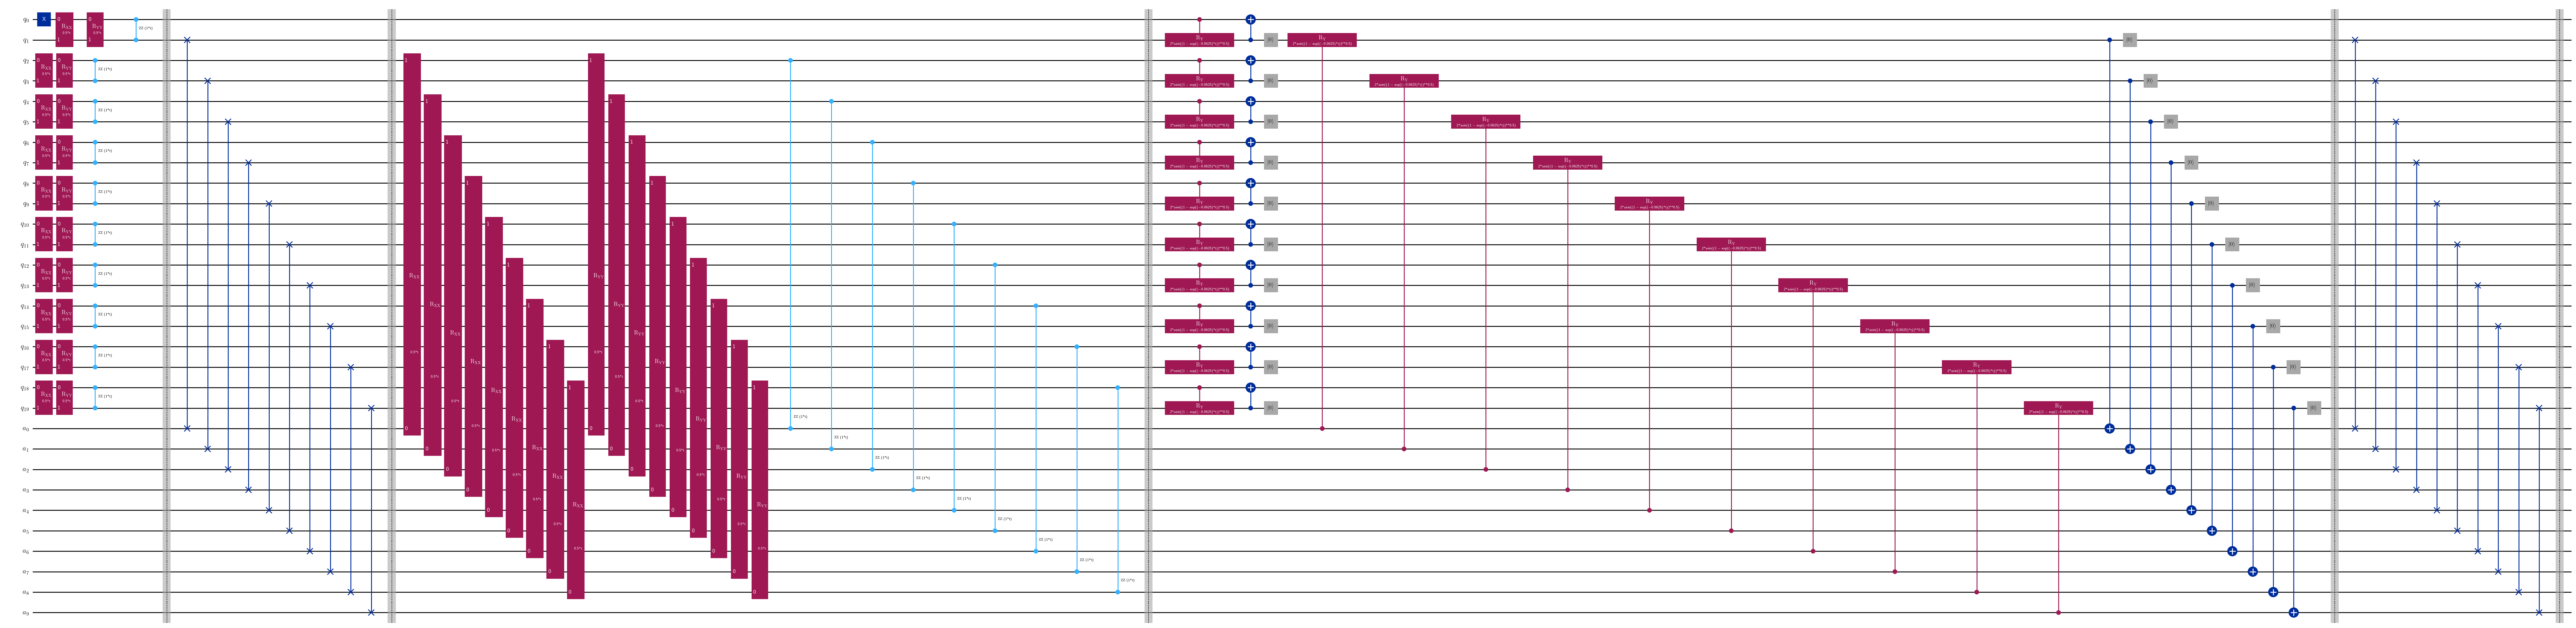

In [4]:
ha_qc.draw('mpl', fold = -1)

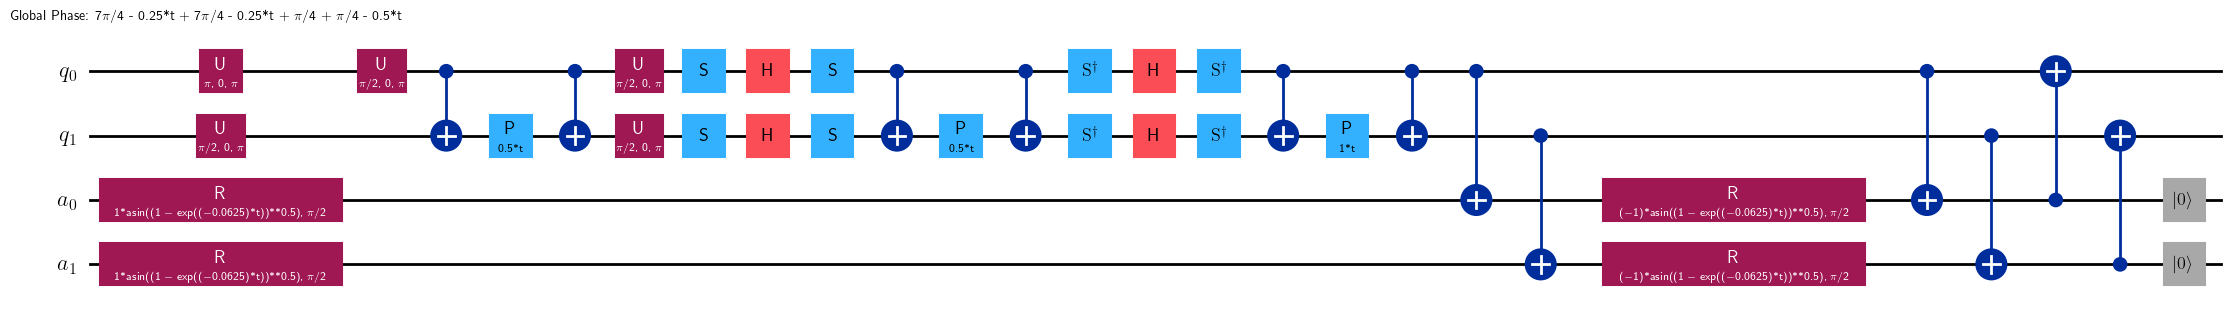

In [12]:
size = 2
J = [1/4]*(size-1)
gamma = [J[0]/4]*size
qc = naive_circuit(J, gamma, size, excited, k, dissipation)
qc.decompose(reps = 2).draw('mpl', fold = -1)

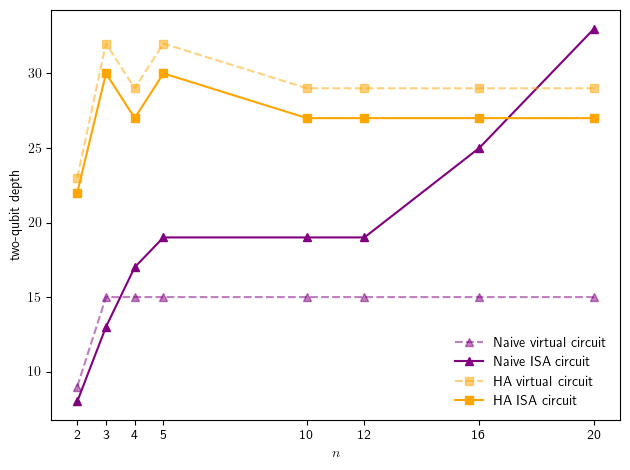

In [ ]:
plt.plot(n, virtual_naive_tqds, marker = '^', color = 'purple', linestyle = "dashed", alpha = 0.5, label = 'Naive virtual circuit')
plt.plot(n, naive_isa_tqds, marker = '^', color = 'purple', label = 'Naive ISA circuit')
plt.plot(n, virtual_ha_tqds, marker = 's', color = 'orange', linestyle = "dashed", alpha = 0.5, label = 'HA virtual circuit')
plt.plot(n, ha_isa_tqds, marker = 's', color = 'orange', label = 'HA ISA circuit')
plt.xlabel("$n$")
plt.ylabel("two-qubit depth")
plt.legend(frameon = False)
plt.xticks(n, n)
plt.tight_layout()
plt.savefig("[LARGER_SIZES]tqd_scaling_HA_adc.png", bbox_inches='tight', transparent = True)
plt.show()

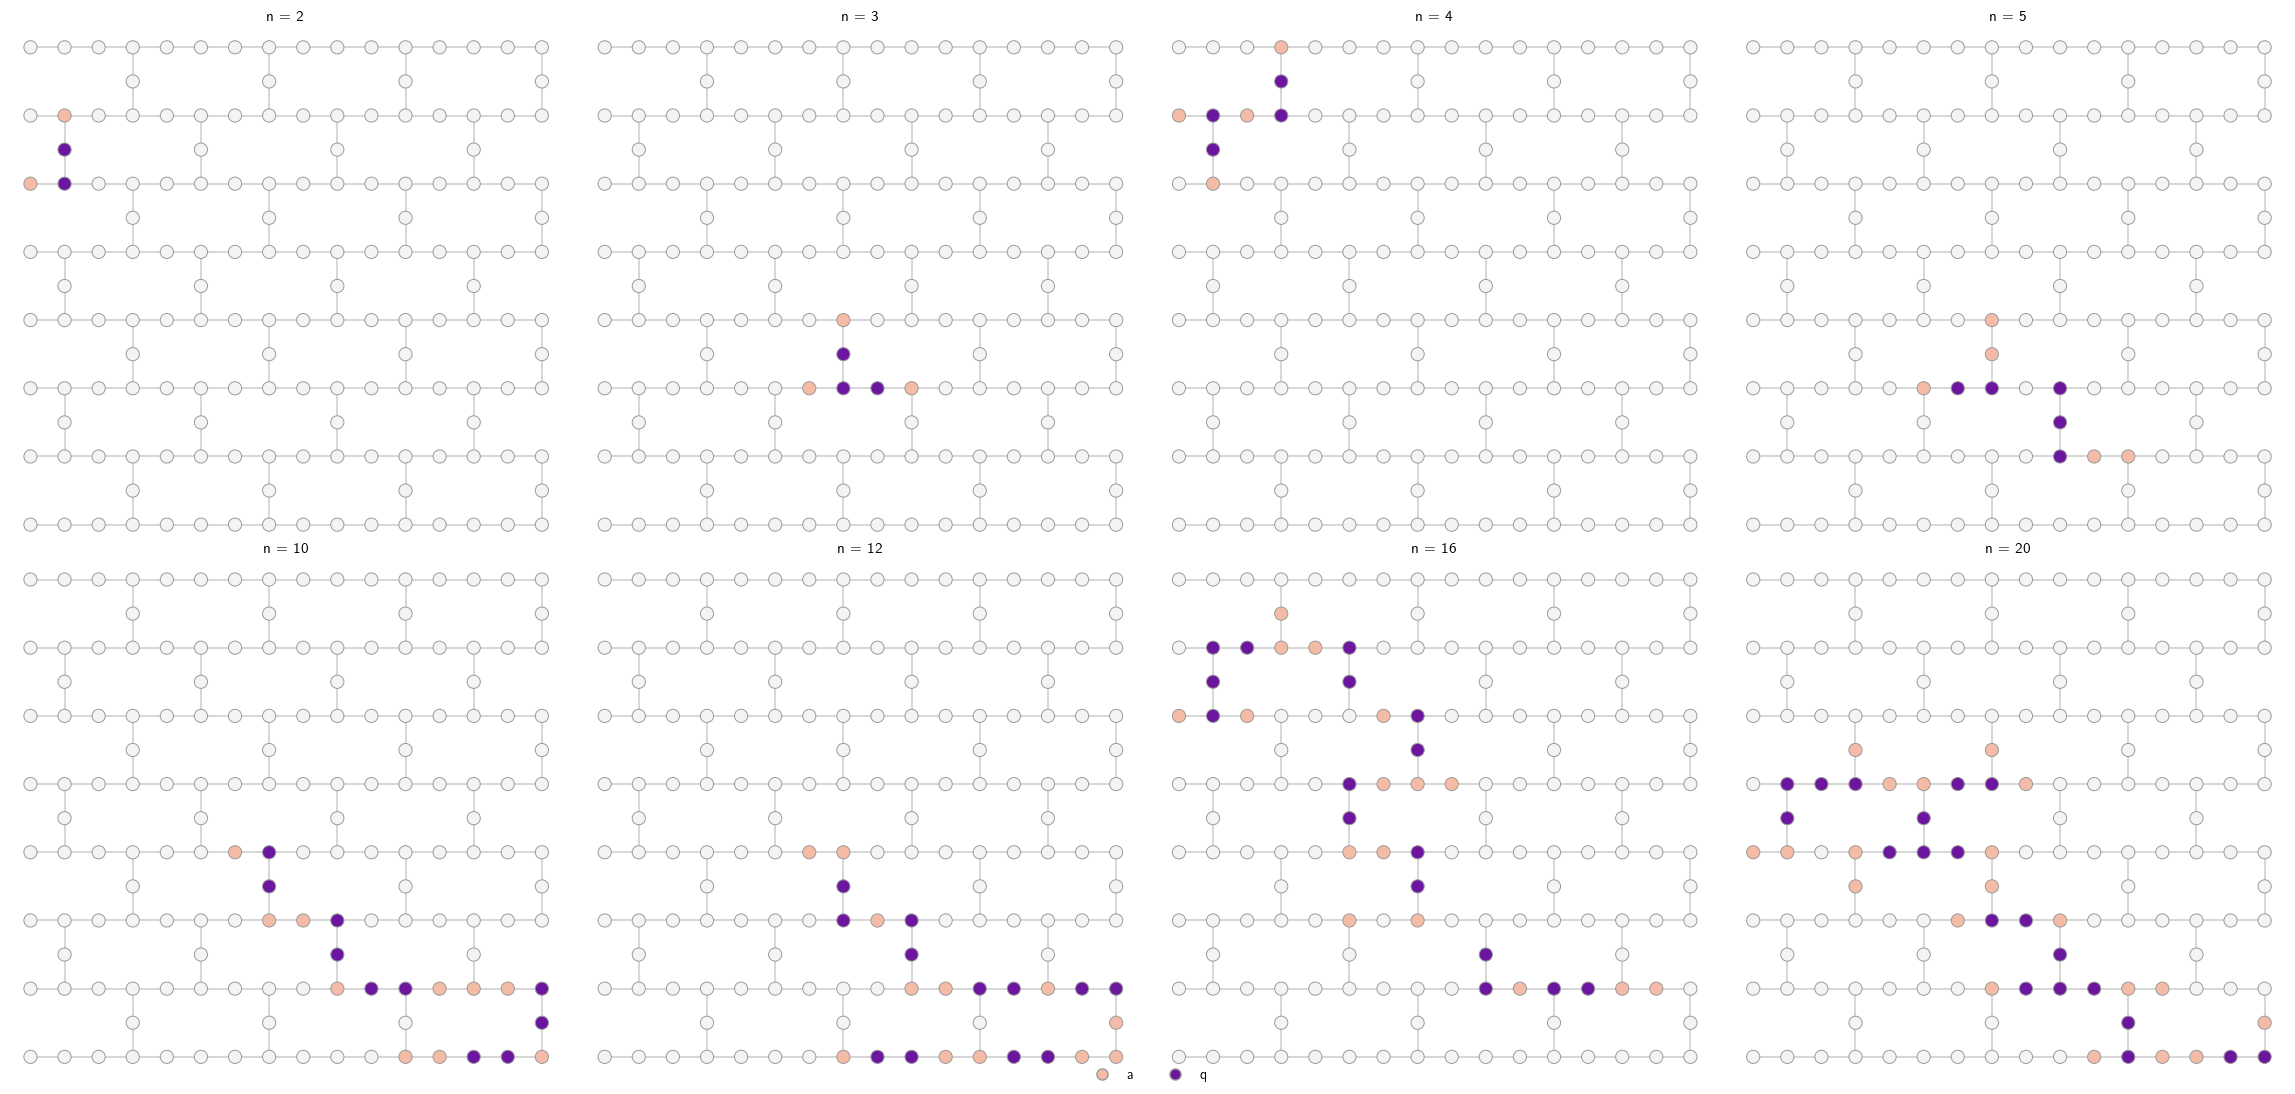

In [7]:
from plot_initial_layout import plot_layouts
fig, axes = plot_layouts(isa_qcs, backend, titles=[f"n = {s}" for s in n])
fig.savefig("[COLORED]initial_layouts_in_ISA_naive_adc_ibm_basquecountry.png", transparent = True, bbox_inches='tight')